<a href="https://colab.research.google.com/github/mistyvisty/amazon-catalog-quality-gate/blob/main/Amazon_Catalog_Quality_Gate_CNN_ResNet_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle credentials set securely!")

Kaggle credentials set securely!


In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small --unzip -p ./data
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:05<00:00, 108MB/s] 

Dataset ready!


In [ ]:
!pip install grad-cam -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFilter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, random, shutil
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda


In [ ]:
df = pd.read_csv('./data/styles.csv', on_bad_lines='skip')
print(df.shape)
print(df.columns.tolist())
print(df['articleType'].value_counts().head(10))

(44424, 10)
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64


In [ ]:
from PIL import ImageEnhance
import random, os, shutil

img_dir = Path('./data/images')
all_images = list(img_dir.glob('*.jpg'))
print(f"Total images found: {len(all_images)}")

random.seed(42)
selected = random.sample(all_images, min(2000, len(all_images)))

for split in ['train', 'val']:
    for cls in ['high_quality', 'low_quality']:
        os.makedirs(f'./dataset/{split}/{cls}', exist_ok=True)

split_idx = int(len(selected) * 0.8)
train_imgs = selected[:split_idx]
val_imgs = selected[split_idx:]

def degrade_image(img):
    choice = random.randint(0, 2)
    if choice == 0:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(3, 6)))
    elif choice == 1:
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(random.uniform(0.1, 0.3))
    else:
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(random.uniform(0.1, 0.3))
    return img

def save_images(img_list, split):
    for img_path in img_list:
        try:
            img = Image.open(img_path).convert('RGB')
            shutil.copy(img_path, f'./dataset/{split}/high_quality/{img_path.name}')
            degraded = degrade_image(img.copy())
            degraded.save(f'./dataset/{split}/low_quality/{img_path.name}')
        except:
            continue

save_images(train_imgs, 'train')
save_images(val_imgs, 'val')
print("Dataset created!")
print(f"Train HQ: {len(os.listdir('./dataset/train/high_quality'))}")
print(f"Train LQ: {len(os.listdir('./dataset/train/low_quality'))}")

Total images found: 44441
Dataset created!
Train HQ: 1600
Train LQ: 1600


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

from torchvision.datasets import ImageFolder

train_dataset = ImageFolder('./dataset/train', transform=train_transform)
val_dataset = ImageFolder('./dataset/val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {train_dataset.classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Classes: ['high_quality', 'low_quality']
Train samples: 3200
Val samples: 800


In [ ]:
class CatalogQualityCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn_model = CatalogQualityCNN().to(device)
print(cnn_model)

CatalogQualityCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_loss += criterion(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_dataset)
        val_acc = val_correct / len(val_dataset)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss/len(train_loader):.3f} | "
              f"Train Acc: {train_acc:.3f} | "
              f"Val Acc: {val_acc:.3f}")

    return history

print("Training CNN from scratch...")
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=10)

Training CNN from scratch...
Epoch 1/10 | Train Loss: 0.247 | Train Acc: 0.898 | Val Acc: 0.964
Epoch 2/10 | Train Loss: 0.091 | Train Acc: 0.973 | Val Acc: 0.978
Epoch 3/10 | Train Loss: 0.072 | Train Acc: 0.979 | Val Acc: 0.975
Epoch 4/10 | Train Loss: 0.041 | Train Acc: 0.990 | Val Acc: 0.983
Epoch 5/10 | Train Loss: 0.037 | Train Acc: 0.989 | Val Acc: 0.976
Epoch 6/10 | Train Loss: 0.033 | Train Acc: 0.990 | Val Acc: 0.988
Epoch 7/10 | Train Loss: 0.038 | Train Acc: 0.990 | Val Acc: 0.986
Epoch 8/10 | Train Loss: 0.022 | Train Acc: 0.994 | Val Acc: 0.973
Epoch 9/10 | Train Loss: 0.042 | Train Acc: 0.989 | Val Acc: 0.981
Epoch 10/10 | Train Loss: 0.029 | Train Acc: 0.992 | Val Acc: 0.991


In [ ]:
resnet_model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze base layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace final layer only
resnet_model.fc = nn.Linear(512, 2)
resnet_model = resnet_model.to(device)

print("Training ResNet-18 (transfer learning)...")
resnet_history = train_model(resnet_model, train_loader, val_loader, epochs=10, lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Training ResNet-18 (transfer learning)...
Epoch 1/10 | Train Loss: 0.264 | Train Acc: 0.907 | Val Acc: 0.984
Epoch 2/10 | Train Loss: 0.106 | Train Acc: 0.973 | Val Acc: 0.986
Epoch 3/10 | Train Loss: 0.072 | Train Acc: 0.983 | Val Acc: 0.989
Epoch 4/10 | Train Loss: 0.053 | Train Acc: 0.988 | Val Acc: 0.996
Epoch 5/10 | Train Loss: 0.048 | Train Acc: 0.988 | Val Acc: 0.998
Epoch 6/10 | Train Loss: 0.038 | Train Acc: 0.991 | Val Acc: 0.996
Epoch 7/10 | Train Loss: 0.046 | Train Acc: 0.985 | Val Acc: 0.995
Epoch 8/10 | Train Loss: 0.035 | Train Acc: 0.993 | Val Acc: 0.998
Epoch 9/10 | Train Loss: 0.037 | Train Acc: 0.991 | Val Acc: 0.999
Epoch 10/10 | Train Loss: 0.027 | Train Acc: 0.994 | Val Acc: 0.999


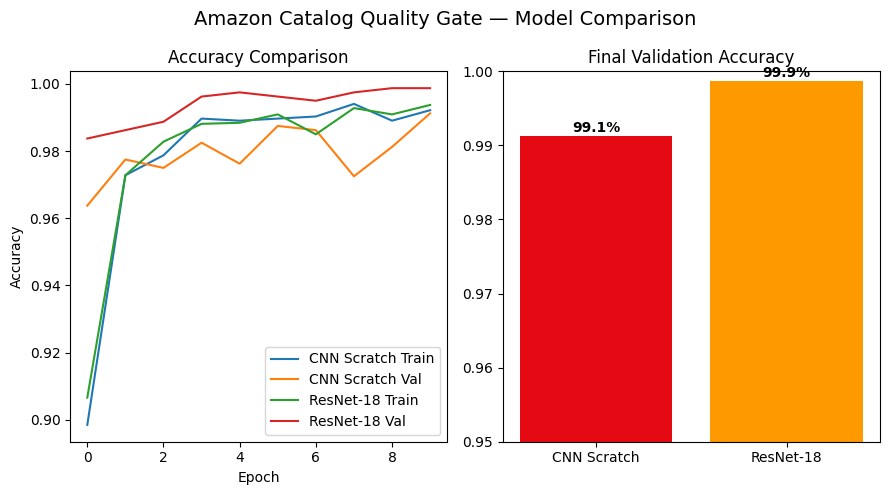

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

axes[0].plot(cnn_history['train_acc'], label='CNN Scratch Train')
axes[0].plot(cnn_history['val_acc'], label='CNN Scratch Val')
axes[0].plot(resnet_history['train_acc'], label='ResNet-18 Train')
axes[0].plot(resnet_history['val_acc'], label='ResNet-18 Val')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

final_cnn = cnn_history['val_acc'][-1]
final_resnet = resnet_history['val_acc'][-1]

axes[1].bar(['CNN Scratch', 'ResNet-18'], [final_cnn, final_resnet],
            color=['#E50914', '#FF9900'])
axes[1].set_title('Final Validation Accuracy')
axes[1].set_ylim(0.95, 1.0)

for i, v in enumerate([final_cnn, final_resnet]):
    axes[1].text(i, v + 0.0005, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Amazon Catalog Quality Gate — Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()

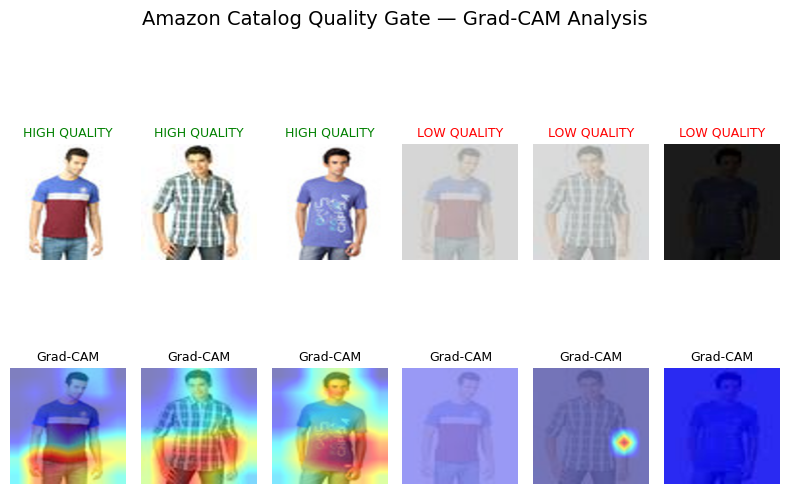

In [ ]:
# Unfreeze resnet for grad-cam
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_model.eval()

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [resnet_model.layer4[-1]]
cam = GradCAM(model=resnet_model, target_layers=target_layers)

val_hq = list(Path('./dataset/val/high_quality').glob('*.jpg'))[:3]
val_lq = list(Path('./dataset/val/low_quality').glob('*.jpg'))[:3]
val_imgs_paths = val_hq + val_lq

fig, axes = plt.subplots(2, 6, figsize=(8, 6))

for idx, img_path in enumerate(val_imgs_paths):
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_np = np.array(img) / 255.0

    input_tensor = val_transform(img).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(0)])[0]

    visualization = show_cam_on_image(img_np.astype(np.float32),
                                      grayscale_cam, use_rgb=True)

    label = 'HIGH QUALITY' if idx < 3 else 'LOW QUALITY'
    color = 'green' if idx < 3 else 'red'

    axes[0][idx].imshow(img)
    axes[0][idx].set_title(label, color=color, fontsize=9)
    axes[0][idx].axis('off')

    axes[1][idx].imshow(visualization)
    axes[1][idx].set_title('Grad-CAM', fontsize=9)
    axes[1][idx].axis('off')

plt.suptitle('Amazon Catalog Quality Gate — Grad-CAM Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

torch.save(resnet_model.state_dict(), 'catalog_quality_resnet.pth')
torch.save(cnn_model.state_dict(), 'catalog_quality_cnn.pth')

files.download('accuracy_comparison.png')
files.download('gradcam_results.png')
print("All saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All saved!
